# Convolutional Neural Network For Handwritten Digit Recognition Using Tensorflow

## Importing Essential Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns 

from PIL import Image

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import image_dataset_from_directory

## Inspecting the Dataset

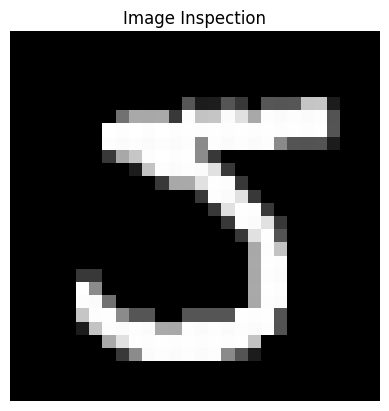

In [2]:
inspection_img = Image.open("../data/mnistmini/training/5/23734.png")

plt.title("Image Inspection")

plt.imshow(inspection_img, cmap = "gray")
plt.axis("off")

plt.show()


## Loading Dataset

In [3]:
train_dataset = image_dataset_from_directory(
    "../data/mnistmini/training",
    validation_split = 0.2,
    subset = "training",
    seed = 67,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 32
)

validation_dataset = image_dataset_from_directory(
    "../data/mnistmini/training",
    validation_split = 0.2,
    subset = "validation",
    seed = 67,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 32
)

test_dataset = image_dataset_from_directory(
    "../data/mnistmini/testing",
    seed = 67,
    color_mode = "grayscale",
    image_size = (28, 28),
    batch_size = 32,
    shuffle = False
)

Found 1000 files belonging to 10 classes.
Using 800 files for training.
Found 1000 files belonging to 10 classes.
Using 200 files for validation.
Found 200 files belonging to 10 classes.


## Model 1 Architecture and Creation

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomTranslation(0.1, 0.1)
])

In [18]:
model = models.Sequential([
    tf.keras.Input(shape = (28, 28, 1)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation = 'relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation = "relu"),
    layers.Dense(10)
])

In [19]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ['accuracy']
)

In [21]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 50
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.2125 - loss: 2.2124 - val_accuracy: 0.5300 - val_loss: 1.8250
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4750 - loss: 1.6913 - val_accuracy: 0.7300 - val_loss: 0.8774
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6025 - loss: 1.2209 - val_accuracy: 0.7950 - val_loss: 0.6402
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6787 - loss: 0.9938 - val_accuracy: 0.8400 - val_loss: 0.4647
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7462 - loss: 0.7726 - val_accuracy: 0.8450 - val_loss: 0.4145
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7887 - loss: 0.6626 - val_accuracy: 0.8900 - val_loss: 0.3203
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8388 - loss: 0.5211 - val_accuracy: 0.9450 - val_loss: 0.2451
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8375 - loss: 0.5451 - val_accuracy: 0.9000 - v

## Model 2 Architecture and Creation

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.02),
    layers.RandomTranslation(0.05, 0.05)
])

In [27]:
modern_model = models.Sequential([
    tf.keras.Input(shape = (28, 28, 1)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation = 'relu'),
    layers.Conv2D(32, (3, 3), activation = 'relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation = "relu"),

    layers.Dropout(0.2),

    layers.Dense(10)
])

In [23]:
modern_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,482 (771.41 KB)

 Trainable params: 197,482 (771.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate = 0.001,
#     decay_steps = 100,
#     decay_rate = 0.95
# )

In [28]:
modern_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits = True
    ),
    metrics = ['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_accuracy",
    patience = 7,
    restore_best_weights = True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.5,
    patience = 3,
    min_lr = 1e-6,
    verbose = 1
)

In [29]:
history = modern_model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 30,
    callbacks = [
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3300 - loss: 1.9202 - val_accuracy: 0.6550 - val_loss: 0.8698 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6950 - loss: 0.9497 - val_accuracy: 0.8700 - val_loss: 0.3789 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8375 - loss: 0.5840 - val_accuracy: 0.9100 - val_loss: 0.3044 - learning_rate: 0.0010
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8662 - loss: 0.4475 - val_accuracy: 0.9500 - val_loss: 0.2121 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9150 - loss: 0.2964 - val_accuracy: 0.9450 - val_loss: 0.2343 - learning_rate: 0.0010
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9175 - loss: 0.2827 - val_accuracy: 0.9450 - val_loss: 0.1976 - learning_rate: 0.0010
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9137 - loss: 0.2321 - val_acc

## Model Evaluation

## Model 1 Evaluation

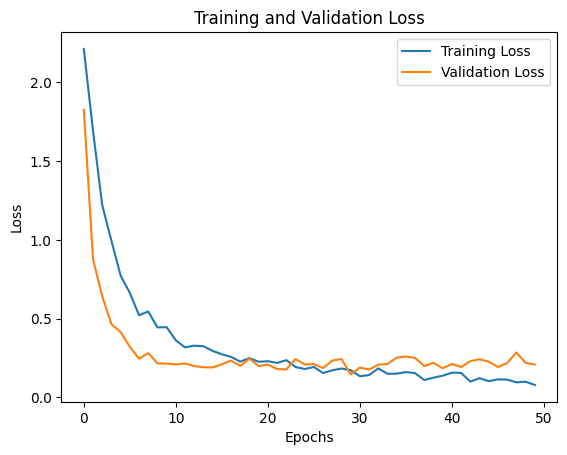

In [22]:
plt.title("Training and Validation Loss")

plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
# plt.grid(True)

plt.show()

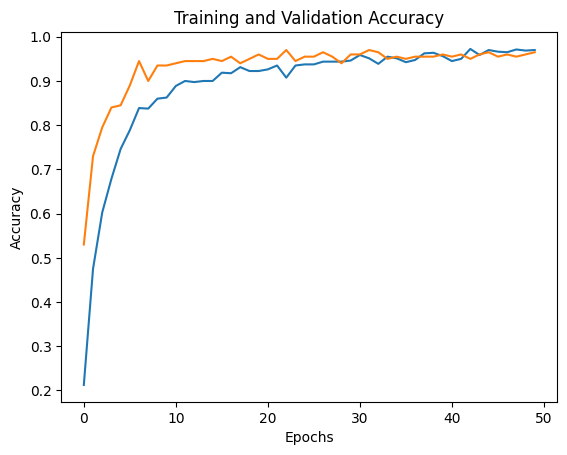

In [23]:
plt.title("Training and Validation Accuracy")

plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

In [24]:
y_true = np.concatenate([y for x, y in test_dataset])

logits = model.predict(test_dataset)
y_preds = np.argmax(logits, axis = 1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


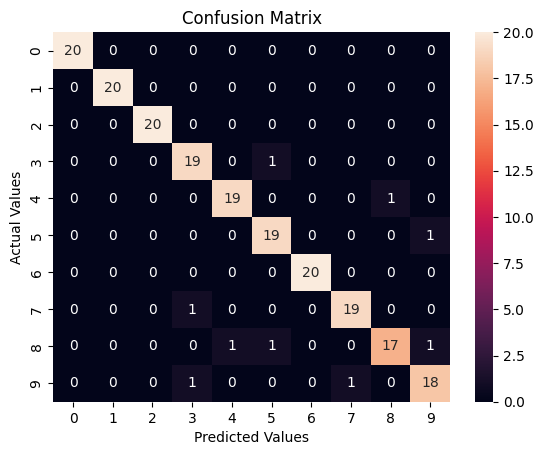

In [26]:
cm = confusion_matrix(y_true, y_preds)

plt.title("Confusion Matrix")

sns.heatmap(cm, annot = True)
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

plt.show()

In [27]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       0.90      0.95      0.93        20
           4       0.95      0.95      0.95        20
           5       0.90      0.95      0.93        20
           6       1.00      1.00      1.00        20
           7       0.95      0.95      0.95        20
           8       0.94      0.85      0.89        20
           9       0.90      0.90      0.90        20

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200



## Model 2 Evaluation

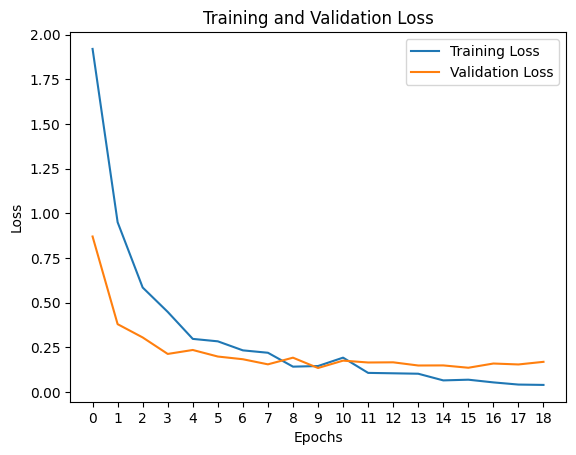

In [38]:
plt.title("Training and Validation Loss")

plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(range(len(history.history["loss"])))
plt.legend()

plt.show()

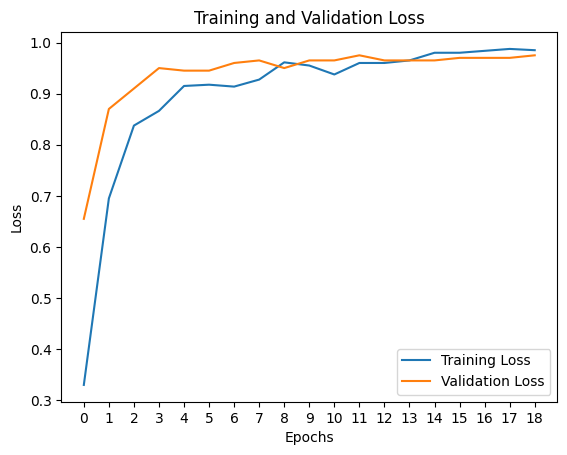

In [39]:
plt.title("Training and Validation Loss")

plt.plot(history.history["accuracy"], label = "Training Loss")
plt.plot(history.history["val_accuracy"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(range(len(history.history["accuracy"])))
plt.legend()

plt.show()

In [47]:
y_true = np.concatenate([y for x, y in test_dataset])

logits = modern_model.predict(test_dataset)
y_preds = np.argmax(logits, axis = 1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


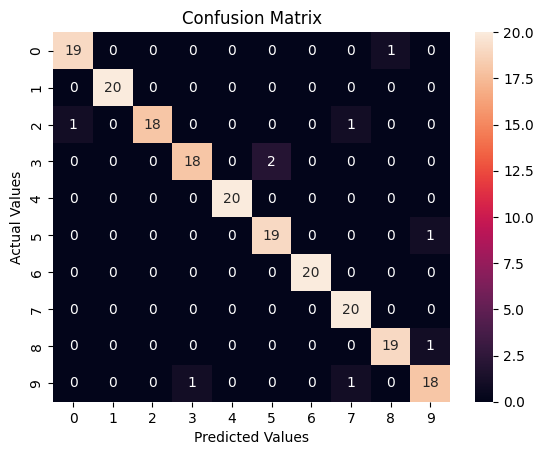

In [48]:
cm = confusion_matrix(y_true, y_preds)

plt.title("Confusion Matrix")
sns.heatmap(cm, annot = True)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [49]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       1.00      1.00      1.00        20
           2       1.00      0.90      0.95        20
           3       0.95      0.90      0.92        20
           4       1.00      1.00      1.00        20
           5       0.90      0.95      0.93        20
           6       1.00      1.00      1.00        20
           7       0.91      1.00      0.95        20
           8       0.95      0.95      0.95        20
           9       0.90      0.90      0.90        20

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200



## Saving the Model and Making Inferences

### Saving Model 1

In [ ]:
model.save("../models/cnn_digit_tensorflow_model.keras")

In [56]:
saved_model = models.load_model("../models/cnn_digit_tensorflow_model.keras")

### Saving Updated Model

In [50]:
modern_model.save("../models/cnn_digit_tensorflow_updated_model.keras")

In [51]:
saved_model = models.load_model("../models/cnn_digit_tensorflow_updated_model.keras")

In [52]:
def predict_digit(image_path):
    image = Image.open(image_path).convert("L")
    
    plt.title("Acutal Digit")
    plt.imshow(image, cmap = "gray")
    plt.axis("off")
    plt.show()

    image = image.resize((28, 28))

    img_array = np.array(image, dtype = np.float32)
    img_array = np.expand_dims(img_array, axis = -1)
    img_array = np.expand_dims(img_array, axis = 0)

    logits = saved_model.predict(img_array, verbose = 0)
    predicted_digit = np.argmax(logits, axis = 1)

    print(f"Predicted Digit: {predicted_digit[0]}")

### Predicting Using Model 1

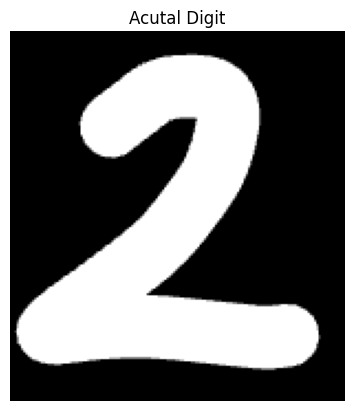

Predicted Digit: 2


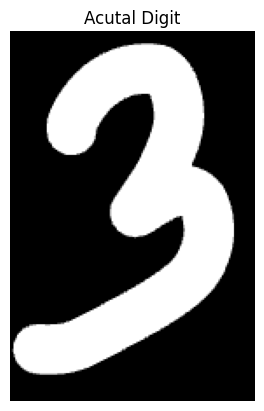

Predicted Digit: 3


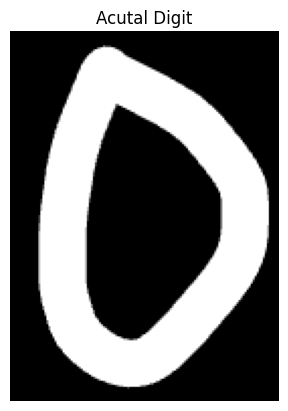

Predicted Digit: 0


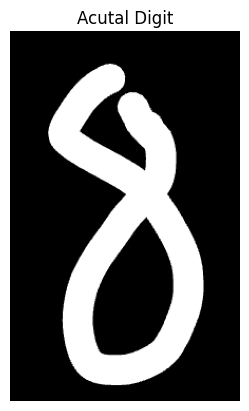

Predicted Digit: 3


In [57]:
predict_digit('../data/mnistmini/extra/Two.png')
predict_digit('../data/mnistmini/extra/Three.png')
predict_digit('../data/mnistmini/extra/Zero.png')
predict_digit('../data/mnistmini/extra/Eight.png')

### Predicting Using Updated Model

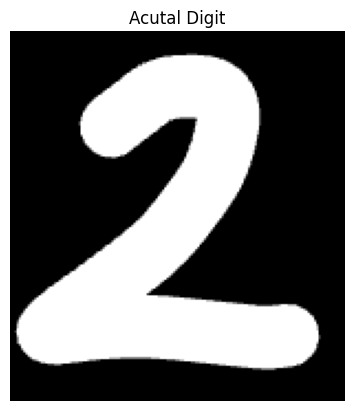

Predicted Digit: 2


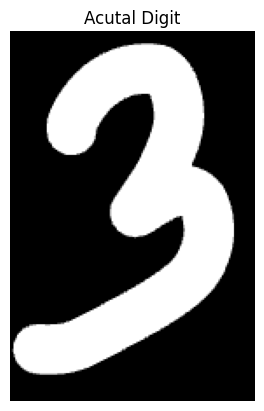

Predicted Digit: 3


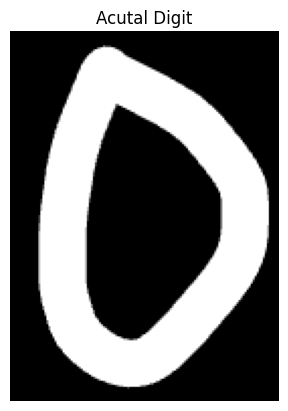

Predicted Digit: 0


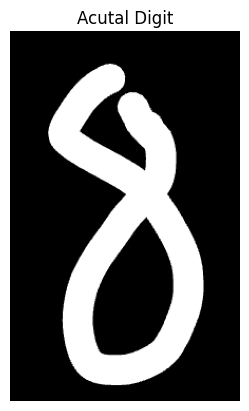

Predicted Digit: 8


In [54]:
predict_digit('../data/mnistmini/extra/Two.png')
predict_digit('../data/mnistmini/extra/Three.png')
predict_digit('../data/mnistmini/extra/Zero.png')
predict_digit('../data/mnistmini/extra/Eight.png')